#### Logical Operations

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

% matplotlib inline

UsageError: Line magic function `%` not found.


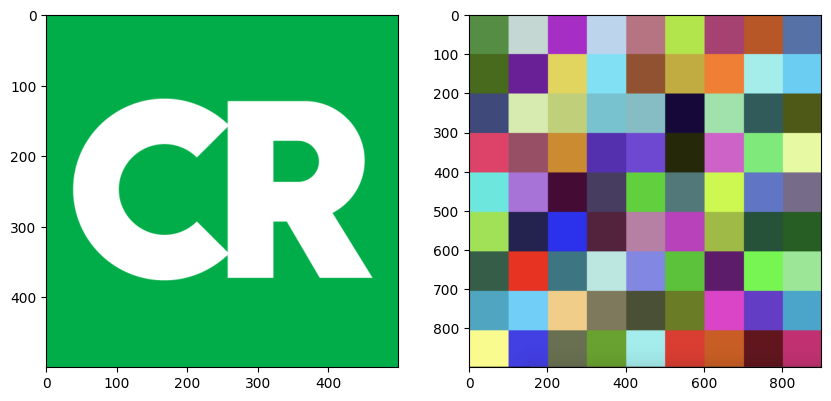

In [32]:
img1 = cv2.imread('data/images/CR_Logo.png', cv2.IMREAD_COLOR)
img2 = cv2.imread('data/images/checkerboard_color.png', cv2.IMREAD_COLOR)

plt.figure(figsize=(10, 10))
plt.subplot(121);plt.imshow(img1[...,::-1]);
plt.subplot(122);plt.imshow(img2[...,::-1]);

In [33]:
img1.shape, img2.shape

((500, 500, 3), (900, 900, 3))

In [34]:
dim = (img1.shape[0], img1.shape[1])
img2 = cv2.resize(img2, dim, interpolation=cv2.INTER_AREA)
img2.shape

(500, 500, 3)

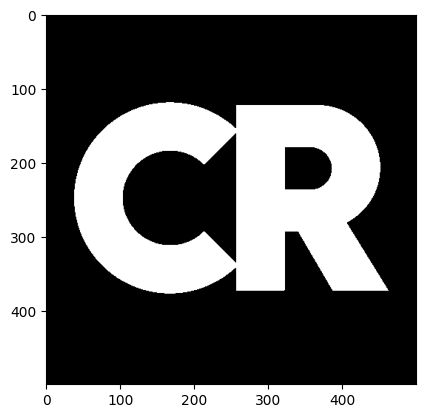

In [35]:
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(img1_gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(mask, cmap="gray")

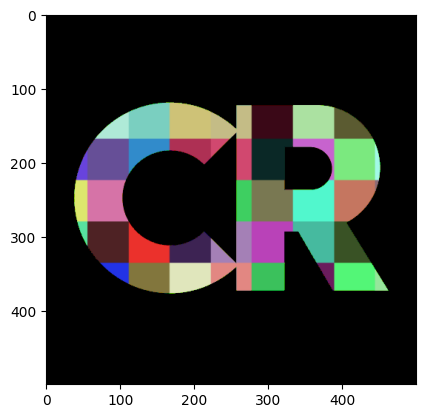

In [36]:
img_bg = cv2.bitwise_and(img1, img2, mask=mask)
plt.imshow(img_bg)

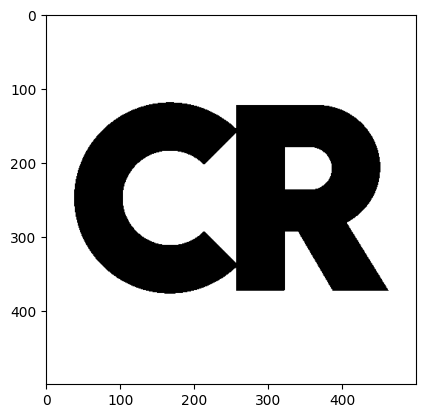

In [37]:
invMask = cv2.bitwise_not(mask)
plt.imshow(invMask, cmap="gray")

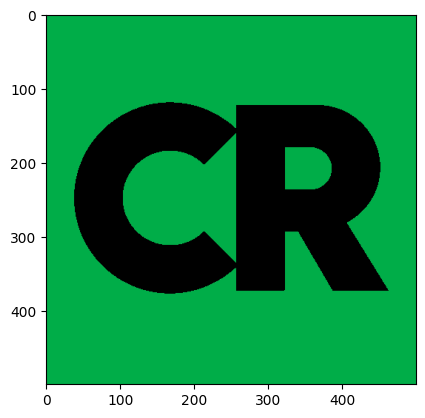

In [38]:
img_foreground = cv2.bitwise_and(img1, img1, mask=invMask)
plt.imshow(img_foreground[...,::-1])


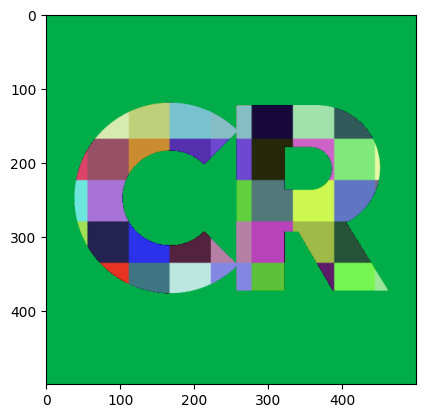

In [40]:
res = cv2.bitwise_or(img_foreground, img_bg, mask=None)
plt.imshow(res[...,::-1])

#### Exercise 2

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

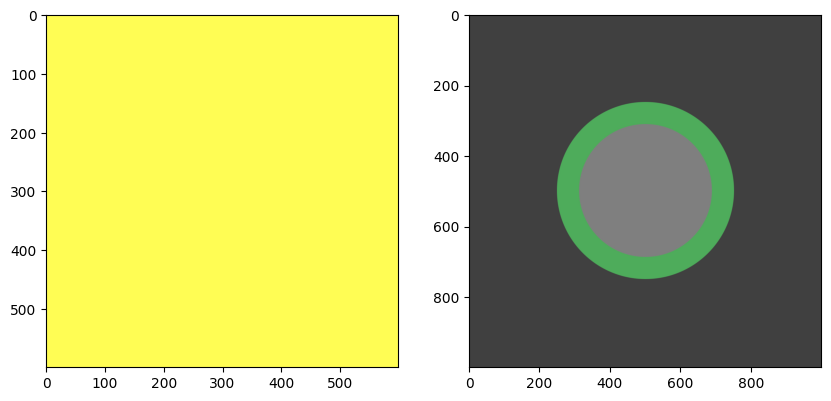

In [46]:
img_yellow_square = cv2.imread('data/images/yellow_square.png', cv2.IMREAD_COLOR)
img_green_circle = cv2.imread('data/images/green_circle.png', cv2.IMREAD_COLOR)

plt.figure(figsize=(10, 10))
plt.subplot(121);plt.imshow(img_yellow_square[...,::-1])
plt.subplot(122);plt.imshow(img_green_circle[...,::-1])

(600, 600, 3) (600, 600, 3)


(600, 600, 3)

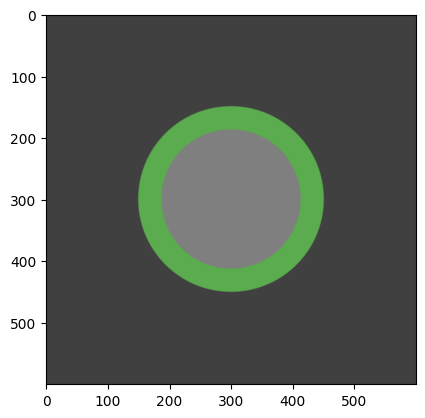

In [51]:
print(img_yellow_square.shape, img_green_circle.shape)

dsize = (img_yellow_square.shape[0], img_yellow_square.shape[1])
img_green_circle = cv2.resize(img_green_circle, dsize, interpolation=cv2.INTER_AREA)
plt.imshow(img_green_circle)
img_green_circle.shape

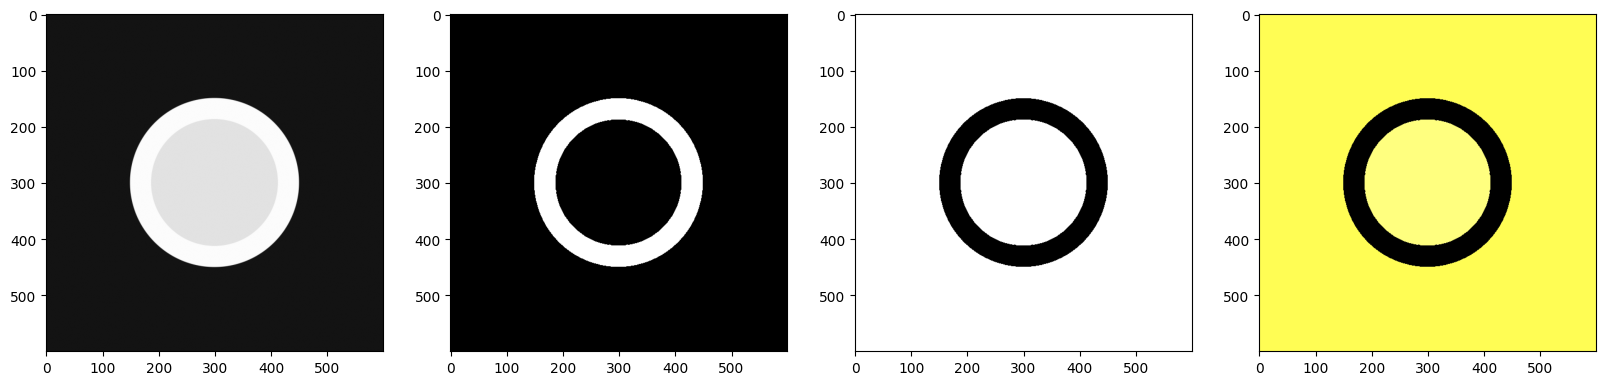

In [76]:
# convert green circle to grayscale and threshold
img_gc = cv2.cvtColor(img_green_circle, cv2.COLOR_BGR2GRAY)
_, img_thresh = cv2.threshold(img_gc, 127, 255, cv2.THRESH_BINARY)

img_thresh_inv = cv2.bitwise_not(img_thresh)

combined = cv2.bitwise_or(img_yellow_square, img_green_circle, mask = img_thresh_inv)

plt.figure(figsize=(20, 10))
plt.subplot(141);plt.imshow(img_gc, cmap="gray")
plt.subplot(142);plt.imshow(img_thresh, cmap="gray")
plt.subplot(143);plt.imshow(img_thresh_inv, cmap="gray")
plt.subplot(144);plt.imshow(combined[...,::-1], cmap="gray")

#### Alpha Channel

In [89]:
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

(2436, 2623, 4)


Text(0.5, 1.0, 'Alpha')

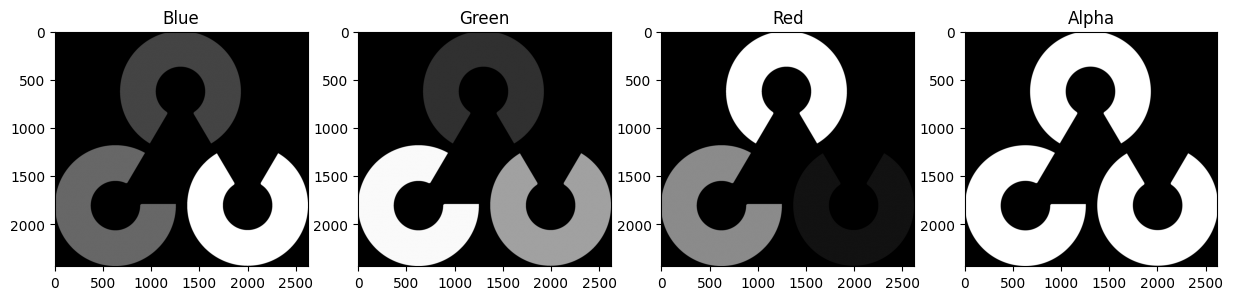

In [93]:
img = cv2.imread('data/images/opencv_logo.png', cv2.IMREAD_UNCHANGED)

print(img.shape)

b, g, r, a = cv2.split(img)

plt.figure(figsize = (15,15))
plt.subplot(141); plt.imshow(b, cmap="gray"); plt.title('Blue')
plt.subplot(142); plt.imshow(g, cmap="gray"); plt.title('Green')
plt.subplot(143); plt.imshow(r, cmap="gray"); plt.title('Red')
plt.subplot(144); plt.imshow(a, cmap="gray"); plt.title('Alpha')

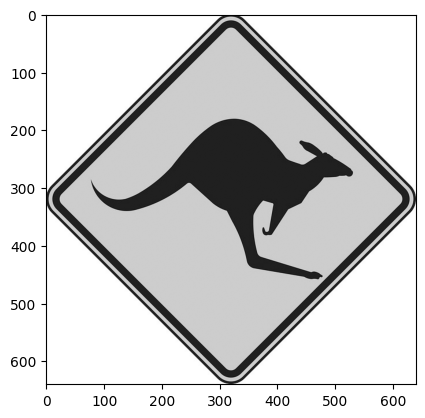

In [95]:
img2 = cv2.imread('data/images/kangaroo.jpg', cv2.IMREAD_COLOR)

img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.imshow(img2_gray, cmap="gray")

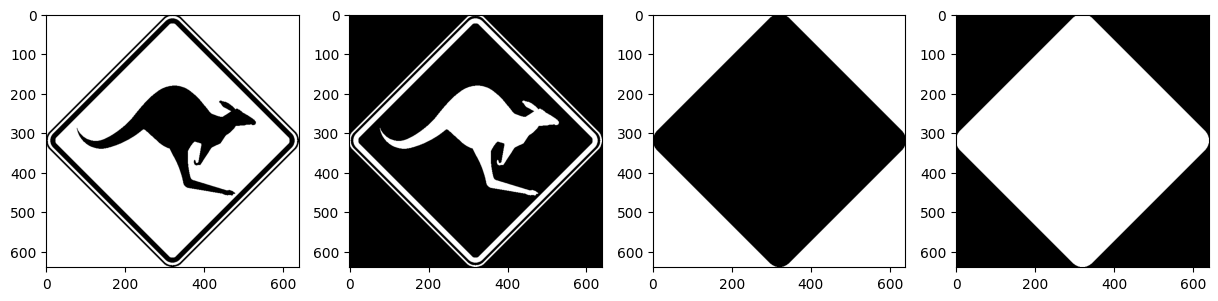

In [107]:
_, dst = cv2.threshold(img2_gray, 127, 255, cv2.THRESH_BINARY)
_, dst1 = cv2.threshold(img2_gray, 230, 255, cv2.THRESH_BINARY)

dst_inv = cv2.bitwise_not(dst)
dst_inv1 = cv2.bitwise_not(dst1)

plt.figure(figsize=(15, 10))
plt.subplot(141);plt.imshow(dst, cmap="gray")
plt.subplot(142);plt.imshow(dst_inv, cmap="gray")
plt.subplot(143);plt.imshow(dst1, cmap="gray")
plt.subplot(144);plt.imshow(dst_inv1, cmap="gray")

In [129]:
# add the alpha channel to the original image and save the image
b, g, r = cv2.split(img2)
mat = [b, g, r, dst_inv1]

finalImage = cv2.merge(mat)

cv2.imwrite('Kangaroo_with_alpha.png', finalImage)


True

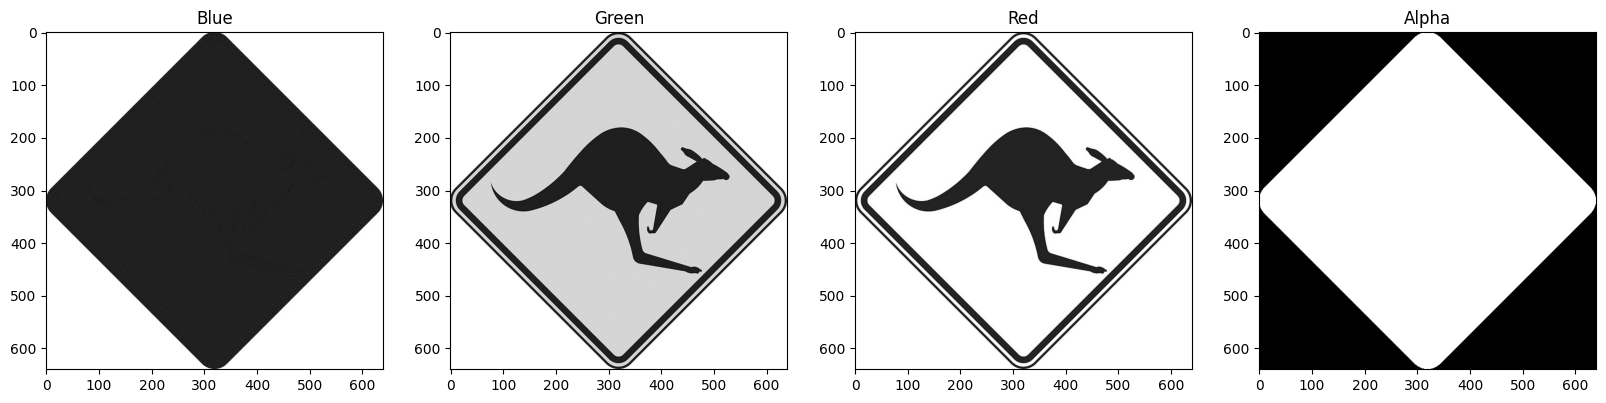

In [136]:
# Actual image in the folder is correct, somehow the its not showing the final image here
img = cv2.imread('data/images/Kangaroo_with_alpha.png', cv2.IMREAD_UNCHANGED)

b, g, r, a = cv2.split(img)

# Display each of the channels.
plt.figure(figsize = (20,15))
plt.subplot(141); plt.imshow(b, cmap="gray"); plt.title('Blue')
plt.subplot(142); plt.imshow(g, cmap="gray"); plt.title('Green')
plt.subplot(143); plt.imshow(r, cmap="gray"); plt.title('Red')
plt.subplot(144); plt.imshow(a, cmap="gray"); plt.title('Alpha');

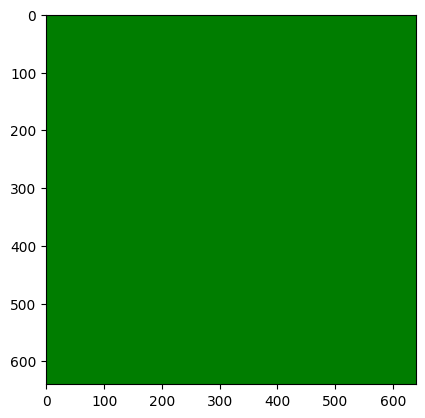

In [118]:
ones = np.ones(dst.shape, dtype="uint8")
ones = ones * 125
zeros = np.zeros(dst.shape, dtype="uint8")
mat = [zeros, ones, zeros]
green_square = cv2.merge(mat)

plt.imshow(green_square[...,::-1])

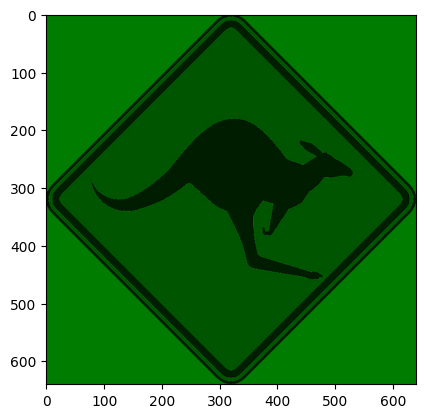

In [128]:
x = cv2.bitwise_and(green_square, img2, dst_inv)
plt.imshow(x[...,::-1])